# PL player value predictor: exploration and experiments

This notebook walks through the data, the model, and the experiments behind the
choices in `src/`. It is meant to be read top to bottom, and every result is
recomputed from the code in the repo, so it stays honest as the pipeline changes.

**Before running:** build the dataset with `python -m src.data.build_dataset`
(needs the API key in `.env`; see the README).

Contents:
1. The data
2. What drives market value
3. The model and how well it does
4. Experiment log: what helped, what didn't
5. Who does the model think is over- or under-valued?

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import PROCESSED_DATASET_PATH
from src.features import CATEGORICAL_FEATURES, NUMERIC_FEATURES, add_derived_features
from src.model import build_pipeline, cross_validate_model, fit_pipeline, value_weights

pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

raw = pd.read_csv(PROCESSED_DATASET_PATH)
df = add_derived_features(raw)
print(f"{len(df)} players, {df.club.nunique()} clubs")

540 players, 20 clubs


## 1. The data

One row per player in a current Premier League squad. Three sources are joined by name:

| Source | Gives us |
|---|---|
| Transfermarkt (scraped) | market value (the target), age, position, club |
| football-data.org | goals, assists, penalties, appearances, summed over 2023–2025 (scorers only) |
| Fantasy Premier League API (bootstrap) | this season's minutes and starts (plus xG/xA, defensive stats, which we don't use yet) |
| Fantasy Premier League API (per-player history) | minutes, starts, goals, assists and xG/xA for each past PL season |

The per-player history costs one request per player, so it's fetched once and cached for 30 days.

In [2]:
raw.head(8)

,name,position,age,nationality,club,market_value_eur,goals,assists,penalties,appearances,...,fpl_gameweeks,has_fpl_record,hist_minutes,hist_starts,hist_goals,hist_assists,hist_xg,hist_xa,hist_seasons,has_hist_record
0,David Raya,Goalkeeper,31,Spain,Arsenal FC,30000000.0,0,0,0,0,...,4,1,9630,107,0,0,0.00,0.14,3,1
1,Illan Meslier,Goalkeeper,26,France,Arsenal FC,8000000.0,0,0,0,0,...,4,1,0,0,0,0,0.00,0.00,1,1
2,Kepa Arrizabalaga,Goalkeeper,31,Spain,Arsenal FC,5000000.0,0,0,0,0,...,4,1,2880,32,0,0,0.06,0.03,3,1
3,William Saliba,Centre-Back,25,France,Arsenal FC,100000000.0,5,1,0,104,...,4,1,9073,103,5,1,5.00,3.39,3,1
4,Gabriel,Centre-Back,28,Brazil,Arsenal FC,75000000.0,0,0,0,0,...,4,1,8155,92,9,8,10.12,3.61,3,1
5,Piero Hincapié,Centre-Back,24,Ecuador,Arsenal FC,50000000.0,1,2,0,30,...,4,1,1787,20,1,2,0.36,1.67,1,1
6,Ezri Konsa,Centre-Back,28,England,Arsenal FC,45000000.0,3,0,0,70,...,4,1,9040,102,3,2,5.12,2.21,3,1
7,Cristhian Mosquera,Centre-Back,22,Spain,Arsenal FC,40000000.0,0,0,0,0,...,4,1,986,9,0,0,0.10,0.63,1,1


### Coverage matters more than it looks

football-data.org only lists players with a goal or assist, so most defenders and
keepers have *no* stats rather than zero stats. The model gets a `has_scorer_record`
flag so it can tell "no data" from "played and didn't score".

The FPL per-player history doesn't have that problem: it covers everyone who was in the game,
defenders and keepers included. That's why it turned out to be the most useful source. Its own
gap is different: a quarter of the squad (signings from abroad, academy players) has no PL
history at all, which `has_hist_record` flags.

In [3]:
coverage = pd.DataFrame(
    {
        "has football-data.org stats (scorers only)": raw.has_scorer_record.mean(),
        "has FPL record": raw.has_fpl_record.mean(),
        "played minutes this season": (raw.fpl_minutes > 0).mean(),
        "has past-season FPL history": raw.has_hist_record.mean(),
        "played minutes in past seasons": (raw.hist_minutes > 0).mean(),
    },
    index=["share of dataset"],
).T
coverage.style.format("{:.0%}")

,share of dataset
has football-data.org stats (scorers only),51%
has FPL record,96%
played minutes this season,74%
has past-season FPL history,75%
played minutes in past seasons,70%


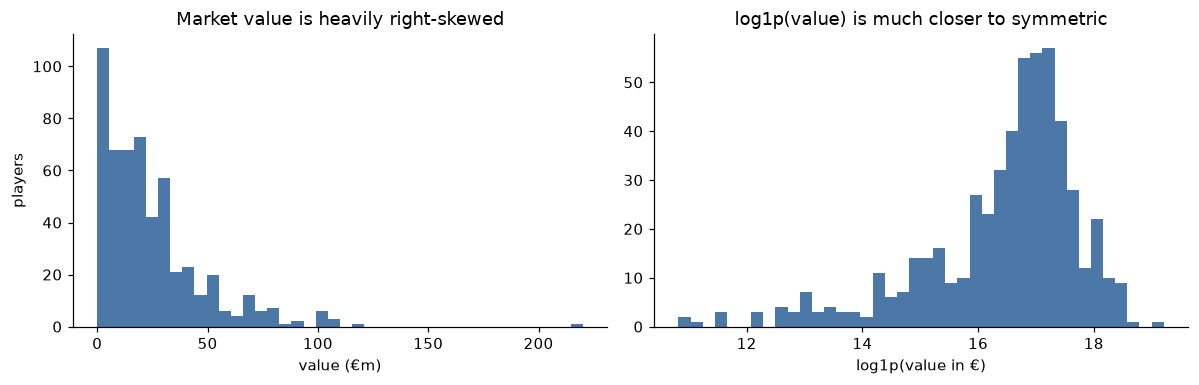

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(df.market_value_eur / 1e6, bins=40, color="#4c78a8")
axes[0].set(title="Market value is heavily right-skewed", xlabel="value (€m)", ylabel="players")
axes[1].hist(np.log1p(df.market_value_eur), bins=40, color="#4c78a8")
axes[1].set(title="log1p(value) is much closer to symmetric", xlabel="log1p(value in €)")
fig.tight_layout()

The skew is why the target is `log1p(value)`. A side effect: the model minimises *relative*
error, which matters in section 4.

## 2. What drives market value

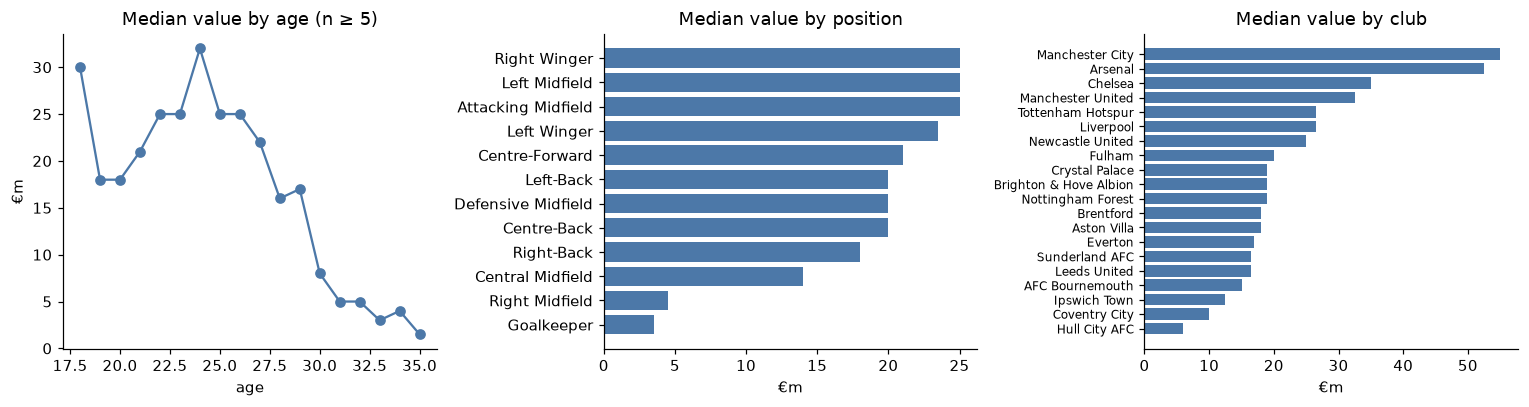

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

by_age = df.groupby("age").market_value_eur.agg(["median", "size"])
by_age = by_age[by_age["size"] >= 5]
axes[0].plot(by_age.index, by_age["median"] / 1e6, "o-", color="#4c78a8")
axes[0].set(title="Median value by age (n ≥ 5)", xlabel="age", ylabel="€m")

order = df.groupby("position").market_value_eur.median().sort_values()
axes[1].barh(order.index, order / 1e6, color="#4c78a8")
axes[1].set(title="Median value by position", xlabel="€m")

order = df.groupby("club").market_value_eur.median().sort_values()
axes[2].barh([c.replace(" FC", "") for c in order.index], order / 1e6, color="#4c78a8")
axes[2].set(title="Median value by club", xlabel="€m")
axes[2].tick_params(axis="y", labelsize=8)
fig.tight_layout()

Value peaks in the mid-20s and falls either side, so a straight line in age is the wrong
shape. That's why the model has `age_squared`. Club matters a lot too, since the same
player is worth more at a bigger club.

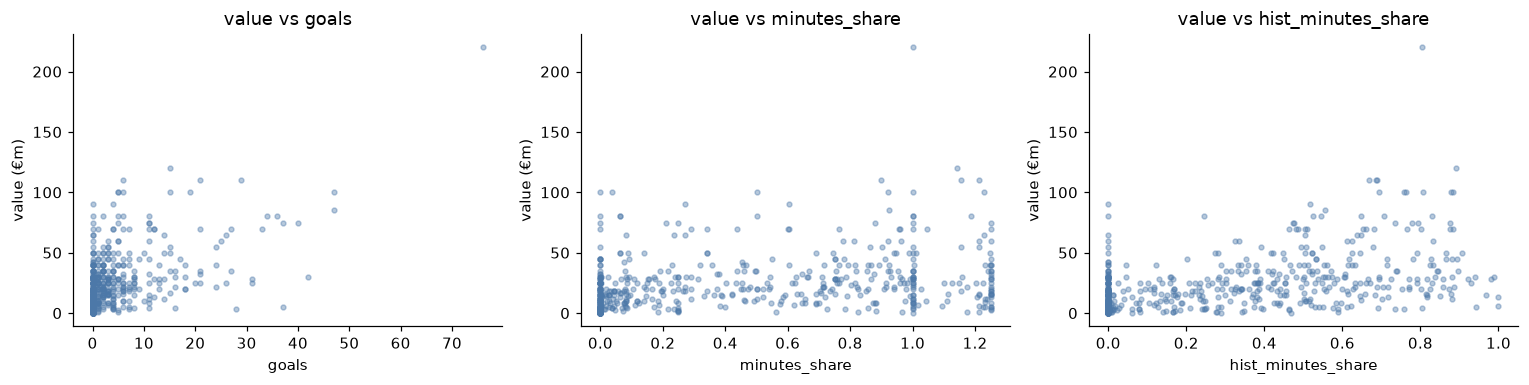

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, col in zip(axes, ["goals", "minutes_share", "hist_minutes_share"]):
    ax.scatter(df[col], df.market_value_eur / 1e6, s=10, alpha=0.4, color="#4c78a8")
    ax.set(xlabel=col, ylabel="value (€m)", title=f"value vs {col}")
fig.tight_layout()

Goals only matter for the few players who have them (most of the dataset sits at zero).
The two playing-time features separate regulars from squad players across *all* positions.
`hist_minutes_share` (past seasons) is the stronger of the two: it's a settled picture rather
than four gameweeks of noise, and a 0 there usually means genuinely new to the league rather
than merely rotated.

## 3. The model and how well it does

In [7]:
print("Numeric features:    ", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)
print()
print("Pipeline: StandardScaler on numeric + one-hot on categorical -> LinearRegression")

Numeric features:     ['age', 'age_squared', 'goals', 'assists', 'penalties', 'appearances', 'has_scorer_record', 'has_fpl_record', 'minutes_share', 'starts_share', 'has_hist_record', 'hist_minutes_share']
Categorical features: ['position', 'club']

Pipeline: StandardScaler on numeric + one-hot on categorical -> LinearRegression


In [8]:
metrics = cross_validate_model(df)
pd.Series(
    {
        "R² (log value)": f"{metrics['cv_r2_log']:.3f}",
        "MAE": f"€{metrics['cv_mae_eur'] / 1e6:.1f}m",
        "RMSE": f"€{metrics['cv_rmse_eur'] / 1e6:.1f}m",
        "MAE, top 10% most valuable": f"€{metrics['cv_top_decile_mae_eur'] / 1e6:.1f}m",
        "predicted/actual, top 10%": f"{metrics['cv_top_decile_ratio']:.2f}  (1.0 = unbiased)",
    },
    name="5-fold cross-validation",
).to_frame()

,5-fold cross-validation
R² (log value),0.650
MAE,€8.1m
RMSE,€11.6m
"MAE, top 10% most valuable",€19.4m
"predicted/actual, top 10%",0.87 (1.0 = unbiased)


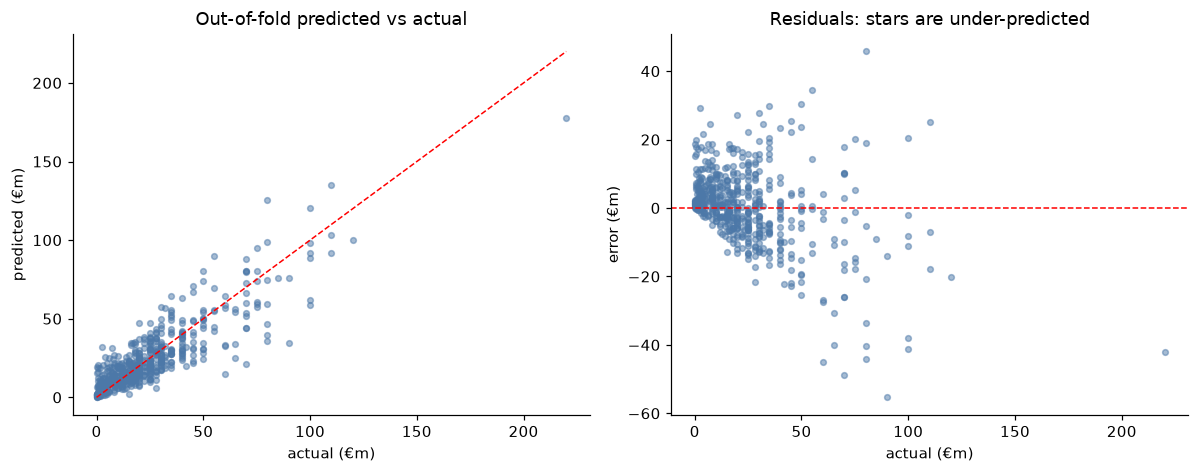

In [9]:
# Out-of-fold predictions: every player is predicted by a model that never saw them.
from sklearn.model_selection import KFold

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = np.log1p(df.market_value_eur)
oof = pd.Series(0.0, index=df.index)
for tr, te in KFold(5, shuffle=True, random_state=42).split(X):
    oof.iloc[te] = fit_pipeline(build_pipeline(), X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])
df["predicted_eur"] = np.expm1(oof)
df["error_eur"] = df.predicted_eur - df.market_value_eur

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(df.market_value_eur / 1e6, df.predicted_eur / 1e6, s=14, alpha=0.5, color="#4c78a8")
lim = df.market_value_eur.max() / 1e6
axes[0].plot([0, lim], [0, lim], "r--", lw=1)
axes[0].set(xlabel="actual (€m)", ylabel="predicted (€m)", title="Out-of-fold predicted vs actual")
axes[1].scatter(df.market_value_eur / 1e6, df.error_eur / 1e6, s=14, alpha=0.5, color="#4c78a8")
axes[1].axhline(0, color="r", ls="--", lw=1)
axes[1].set(xlabel="actual (€m)", ylabel="error (€m)", title="Residuals: stars are under-predicted")
fig.tight_layout()

The fan shape on the right is the model's main weakness: the more valuable the player,
the more it under-predicts. Regression to the mean explains part of it. The rest is
"star premium" that on-pitch stats in this dataset simply don't capture.

## 4. Experiment log

Everything below is cross-validated (5 folds × 3 repeats), because a single 80/20 split at
this dataset size swings by ~0.1 R². The harness re-fits the pipeline from scratch each fold.

In [10]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

gw = df.fpl_gameweeks.clip(lower=1)
df["xgi_per_gw"] = (df.fpl_xg + df.fpl_xa) / gw
df["def_per_gw"] = df.fpl_defensive_contribution / gw

seasons = df.hist_seasons.clip(lower=1)
df["hist_starts_per_season"] = df.hist_starts / seasons
df["hist_xgi_per90"] = (df.hist_xg + df.hist_xa) / (df.hist_minutes + 900) * 90  # shrunk

values = df.market_value_eur.to_numpy()
y_log = np.log1p(values)
top = values >= np.quantile(values, 0.9)


def cv_eval(numeric, regressor=None, weighted=True, categorical=CATEGORICAL_FEATURES,
            n_repeats=3, target_power=None):
    """Repeated K-fold; returns mean log-R², euro MAE, top-decile MAE and ratio."""
    rows = []
    cv = RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=0)
    for tr, te in cv.split(df):
        pre = ColumnTransformer([
            ("n", StandardScaler(), numeric),
            ("c", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical),
        ])
        pipe = Pipeline([("p", pre), ("r", clone(regressor) if regressor is not None else LinearRegression())])
        cols = numeric + categorical
        fit_kw = {"r__sample_weight": value_weights(values[tr])} if weighted else {}
        pipe.fit(df.iloc[tr][cols], y_log[tr], **fit_kw)
        pred = np.expm1(pipe.predict(df.iloc[te][cols]))
        err = np.abs(pred - values[te])
        t = top[te]
        rows.append([
            1 - ((np.log1p(pred) - y_log[te]) ** 2).sum() / ((y_log[te] - y_log[te].mean()) ** 2).sum(),
            err.mean() / 1e6,
            err[t].mean() / 1e6,
            (pred[t] / values[te][t]).mean(),
        ])
    r = np.nanmean(rows, axis=0)
    return {"R² (log)": r[0], "MAE €m": r[1], "top-10% MAE €m": r[2], "top-10% pred/actual": r[3]}


def table(results):
    return pd.DataFrame(results).T.style.format(
        {"R² (log)": "{:.3f}", "MAE €m": "{:.2f}", "top-10% MAE €m": "{:.1f}", "top-10% pred/actual": "{:.2f}"}
    ).background_gradient(subset=["MAE €m"], cmap="RdYlGn_r")

### 4a. Feature engineering (linear regression, sqrt-value weighting)

In [11]:
base = ["age", "goals", "assists", "penalties", "appearances"]
this_season = ["has_fpl_record", "minutes_share", "starts_share"]

sets = {
    "1. raw stats only": base,
    "2. + age² (value peaks mid-20s)": base + ["age_squared"],
    "3. + has_scorer_record": base + ["age_squared", "has_scorer_record"],
    "4. + this season's playing time": base + ["age_squared", "has_scorer_record"] + this_season,
    "5. + past seasons' minutes (current model)": NUMERIC_FEATURES,
    "6. + past-season starts": NUMERIC_FEATURES + ["hist_starts_per_season"],
    "7. + past-season xG+xA per 90": NUMERIC_FEATURES + ["hist_xgi_per90"],
    "8. + past-season goals & assists": NUMERIC_FEATURES + ["hist_goals", "hist_assists"],
    "9. + this season's xG/xA (re-test)": NUMERIC_FEATURES + ["xgi_per_gw"],
    "10. + this season's defensive stats": NUMERIC_FEATURES + ["def_per_gw"],
    "11. + FPL price (rejected, see below)": NUMERIC_FEATURES + ["fpl_price"],
}
table({name: cv_eval(cols) for name, cols in sets.items()})

,R² (log),MAE €m,top-10% MAE €m,top-10% pred/actual
1. raw stats only,0.361,11.46,27.2,0.77
2. + age² (value peaks mid-20s),0.499,10.03,26.8,0.81
3. + has_scorer_record,0.508,9.93,26.0,0.81
4. + this season's playing time,0.581,9.31,25.2,0.86
5. + past seasons' minutes (current model),0.647,8.27,19.5,0.89
6. + past-season starts,0.645,8.30,19.5,0.89
7. + past-season xG+xA per 90,0.645,8.29,19.5,0.89
8. + past-season goals & assists,0.640,8.28,19.5,0.89
9. + this season's xG/xA (re-test),0.647,8.31,19.9,0.89
10. + this season's defensive stats,0.647,8.33,19.9,0.89


What to take from this:

- **Age² and playing time are the wins.** Age² fixes the wrong-shaped age curve; the two
  playing-time features tell the model who actually plays. Past-season minutes (row 5) is the
  single biggest addition, and it also cuts top-decile error by about a fifth.
- **More history doesn't help** (rows 6-8). Once the model knows *how much* a player played,
  the starts, xG and goals from those same seasons are largely redundant.
- **This season's xG/xA and defensive stats still add nothing** (rows 9-10), as before the
  history was added. Four gameweeks is too few; worth re-testing later in the season.
- **`fpl_price` is rejected.** It lifts log-R² but *worsens* euro error, especially for stars
  (its range is compressed, and it's FPL's own valuation rather than performance).

Worth knowing: dropping the football-data.org stats entirely (keeping age, position, club and
the FPL features) scores within noise of the current model. That API key is carrying very
little weight now that the FPL history covers non-scorers too.

### 4b. Does a fancier model help?

In [12]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

def rf():
    return RandomForestRegressor(300, min_samples_leaf=3, random_state=0, n_jobs=-1)

def gb():
    return GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.05,
                                     subsample=0.8, random_state=0)

cur = NUMERIC_FEATURES
table({
    "Linear, √value weights (current)": cv_eval(cur, n_repeats=2),
    "Linear, unweighted": cv_eval(cur, weighted=False, n_repeats=2),
    "Random forest, √value weights": cv_eval(cur, rf(), n_repeats=2),
    "Random forest, unweighted": cv_eval(cur, rf(), weighted=False, n_repeats=2),
    "Gradient boosting, √value weights": cv_eval(cur, gb(), n_repeats=2),
    "Gradient boosting, unweighted": cv_eval(cur, gb(), weighted=False, n_repeats=2),
})

,R² (log),MAE €m,top-10% MAE €m,top-10% pred/actual
"Linear, √value weights (current)",0.648,8.26,19.4,0.88
"Linear, unweighted",0.680,8.97,21.2,0.92
"Random forest, √value weights",0.560,9.57,30.8,0.67
"Random forest, unweighted",0.621,9.70,34.1,0.60
"Gradient boosting, √value weights",0.632,8.67,26.6,0.73
"Gradient boosting, unweighted",0.670,8.77,28.4,0.68


Every model gets the same features and the same choice of weighting. What to take from this:

- **Linear with √value weights has the lowest euro error**, both overall and for the top 10%.
- **Gradient boosting ties the linear model on log-R² only when both are unweighted**
  (~0.63), and is much more conservative on stars (pred/actual ≈ 0.7 vs ≈ 0.85).
- **Random forest is worst throughout.**

With ~540 rows the extra flexibility of trees isn't buying anything on the metric we care about,
so the simple, explainable model stays. Gradient boosting is the one to revisit if the dataset
grows (e.g. multi-season data).

### 4c. The star-player problem

Plain log-value regression treats a 10% error on a €1m player the same as on a €100m
player, so the many cheap players outvote the few stars. Weighting each player by
√value in training rebalances that:

In [13]:
table({
    "unweighted": cv_eval(NUMERIC_FEATURES, weighted=False),
    "weight ∝ √value (current)": cv_eval(NUMERIC_FEATURES),
})

,R² (log),MAE €m,top-10% MAE €m,top-10% pred/actual
unweighted,0.680,9.00,21.8,0.93
weight ∝ √value (current),0.647,8.27,19.5,0.89


Weighting cuts euro error both overall (€9.9m → €9.3m) and on the top 10% (€29m → €25m). It's a
trade-off, not a free win: log-R² drops (0.62 → 0.58), and the average top-10% pred/actual
ratio is actually slightly *better* unweighted (0.89 vs 0.86). We optimise the euro error
because that's what "how far off is the estimate" means to a user.

The model is still conservative about the very top. Removing that bias with a smearing correction
made the *overall* error worse in earlier experiments (€10.3m → €11.6m), so it's not adopted. The
remaining gap is probably a data problem (no brand/contract/transfer information), not a modelling one.

## 5. Who does the model think is over- or under-valued?

Out-of-fold predictions (section 3), so each player is scored by a model that never saw them.
A large gap doesn't mean Transfermarkt is *wrong*. It means the player is worth more (or
less) than their on-pitch numbers and profile alone would suggest, e.g. a hyped youngster, or
a defender whose value is in things these stats don't measure.

**Read the "history" column**: the number of past PL seasons the model had for that player.
A 0 means a new arrival (or an academy player), so the model is working from age, position,
club and a few gameweeks only, and tends to under-predict them. Several of the biggest
"worth less" gaps below are that artefact rather than a real signal.

In [14]:
cols = ["name", "club", "position", "age", "hist_seasons", "market_value_eur", "predicted_eur"]
gap = df[cols].assign(gap_pct=(df.predicted_eur / df.market_value_eur - 1) * 100)
big = gap[gap.market_value_eur >= 15e6]  # ignore tiny values, where % gaps are meaningless

def show(frame):
    return frame.assign(
        market_value_eur=(frame.market_value_eur / 1e6).round(1),
        predicted_eur=(frame.predicted_eur / 1e6).round(1),
        gap_pct=frame.gap_pct.round(0),
    ).rename(columns={"market_value_eur": "actual €m", "predicted_eur": "predicted €m",
                      "gap_pct": "gap %", "hist_seasons": "history"}
    ).reset_index(drop=True)

print("Model thinks these are worth MORE than Transfermarkt says (players ≥ €15m):")
display(show(big.sort_values("gap_pct", ascending=False).head(10)))
print("Model thinks these are worth LESS:")
display(show(big.sort_values("gap_pct").head(10)))

Model thinks these are worth MORE than Transfermarkt says (players ≥ €15m):


,name,club,position,age,history,actual €m,predicted €m,gap %
0,Allan,Manchester City FC,Right Winger,22,0,20.0,47.1,136.0
1,Dara O'Shea,Ipswich Town FC,Centre-Back,27,2,16.0,34.6,116.0
2,Vitaly Janelt,Brentford FC,Defensive Midfield,28,3,16.0,33.3,108.0
3,Dejan Kulusevski,Tottenham Hotspur FC,Attacking Midfield,26,3,17.0,34.4,102.0
4,Wilson Odobert,Tottenham Hotspur FC,Left Winger,21,3,18.0,35.5,97.0
5,Adrien Truffert,AFC Bournemouth,Left-Back,24,1,30.0,57.7,92.0
6,Jannik Schuster,Brentford FC,Centre-Back,20,0,18.0,34.2,90.0
7,Igor Jesus,Nottingham Forest FC,Centre-Forward,25,1,25.0,47.1,88.0
8,Taylor Harwood-Bellis,Aston Villa FC,Centre-Back,24,1,20.0,37.3,87.0
9,Milos Kerkez,Liverpool FC,Left-Back,22,3,35.0,64.7,85.0


Model thinks these are worth LESS:


,name,club,position,age,history,actual €m,predicted €m,gap %
0,Alisson,Liverpool FC,Goalkeeper,33,0,15.0,2.1,-86.0
1,Djordje Petrovic,AFC Bournemouth,Goalkeeper,26,0,28.0,6.3,-78.0
2,Luka Vuskovic,Brighton & Hove Albion FC,Centre-Back,19,1,60.0,14.9,-75.0
3,Junior Kroupi,AFC Bournemouth,Centre-Forward,20,1,70.0,21.3,-70.0
4,Jack Grealish,Everton FC,Left Winger,31,3,20.0,7.0,-65.0
5,Dominic Solanke,Tottenham Hotspur FC,Centre-Forward,29,0,28.0,10.8,-62.0
6,Bradley Barcola,Liverpool FC,Left Winger,24,0,90.0,34.7,-61.0
7,Johan Manzambi,Aston Villa FC,Attacking Midfield,20,0,65.0,25.1,-61.0
8,Christos Mouzakitis,Hull City AFC,Central Midfield,19,0,25.0,10.1,-60.0
9,Kevin Danso,Sunderland AFC,Centre-Back,28,2,20.0,8.1,-59.0


## Where to go next

- **Re-test the current-season features** as more gameweeks are played. Right now the past
  seasons carry the signal and this season is mostly noise; that balance should shift.
- **Consider dropping football-data.org.** The FPL history covers everyone, not just scorers,
  and removing those stats costs almost nothing — it would also remove the API-key setup step.
- **Contract length and transfer history** (e.g. the Transfermarkt datasets on Kaggle) are the
  most likely source of the missing "star premium", the one thing no current source explains.